In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset

# Load Data
raw_data = load_dataset("lukebarousse/data_jobs")
df = raw_data['train'].to_pandas()

# Cleanup data
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 785741 entries, 0 to 785740
Data columns (total 17 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   job_title_short        785741 non-null  object        
 1   job_title              785740 non-null  object        
 2   job_location           784696 non-null  object        
 3   job_via                785733 non-null  object        
 4   job_schedule_type      773074 non-null  object        
 5   job_work_from_home     785741 non-null  bool          
 6   search_location        785741 non-null  object        
 7   job_posted_date        785741 non-null  datetime64[ns]
 8   job_no_degree_mention  785741 non-null  bool          
 9   job_health_insurance   785741 non-null  bool          
 10  job_country            785692 non-null  object        
 11  salary_rate            33067 non-null   object        
 12  salary_year_avg        22003 non-null   floa

### 🟩 Count Job Postings by Title and Country (2.4.1)

In [2]:

# Using 'count' on any other column except index column, fillna = 0
df.pivot_table(
    index='job_title_short',   
    columns='job_country', 
    values='job_posted_date',  # Any Column can be counted, except job_title_short itself
    aggfunc='count',           # This counts unique values for values, for every intersection
                               # of job_title_short and job_country
    fill_value=0               # Cleanly handles missing combinations as only non-Null values are counted 
)

# Using 'size' which automatically counts the Rows, no need for values pr fill_value because the Rows don't have null values.
df.pivot_table(index = 'job_title_short', columns='job_country', aggfunc='size')

job_country,Afghanistan,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,...,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,4.0,11.0,21.0,1.0,453.0,29.0,928.0,738.0,16.0,5.0,...,984.0,827.0,7382.0,199.0,55.0,2.0,91.0,3.0,30.0,6.0
Cloud Engineer,NaN,1.0,5.0,NaN,322.0,4.0,489.0,266.0,NaN,2.0,...,93.0,193.0,423.0,53.0,3.0,2.0,70.0,NaN,4.0,3.0
Data Analyst,9.0,36.0,22.0,2.0,1273.0,33.0,1658.0,2169.0,21.0,7.0,...,2587.0,10482.0,67816.0,227.0,39.0,16.0,334.0,4.0,40.0,34.0
Data Engineer,NaN,30.0,21.0,3.0,2265.0,45.0,4658.0,2175.0,7.0,14.0,...,1139.0,11807.0,35080.0,248.0,49.0,19.0,768.0,2.0,5.0,11.0
Data Scientist,1.0,12.0,27.0,1.0,1617.0,28.0,1179.0,1709.0,16.0,5.0,...,1360.0,9148.0,58830.0,140.0,50.0,9.0,375.0,NaN,13.0,13.0
Machine Learning Engineer,NaN,4.0,2.0,NaN,287.0,22.0,360.0,305.0,2.0,3.0,...,164.0,317.0,921.0,46.0,22.0,4.0,115.0,NaN,2.0,1.0
Senior Data Analyst,2.0,2.0,NaN,NaN,255.0,22.0,310.0,301.0,2.0,1.0,...,262.0,1356.0,11791.0,50.0,15.0,4.0,71.0,NaN,5.0,1.0
Senior Data Engineer,NaN,6.0,1.0,NaN,647.0,57.0,1482.0,542.0,4.0,12.0,...,227.0,3337.0,9289.0,106.0,54.0,4.0,220.0,NaN,NaN,3.0
Senior Data Scientist,NaN,11.0,NaN,1.0,350.0,16.0,302.0,451.0,1.0,1.0,...,245.0,2367.0,12946.0,54.0,19.0,3.0,91.0,NaN,2.0,1.0


### 🟨 Salary Stats by Job Title (2.4.2)

In [3]:
df.pivot_table(index = 'job_title_short', values='salary_year_avg', aggfunc=['mean', 'max', 'min']) # Columns not needed here, as it is pointless

# We can though, find the salary statistics grouped by job_country
df.pivot_table(index='job_title_short', columns='job_country', values='salary_year_avg', aggfunc=['mean'], fill_value=0, margins=True)

mean                                    \
job_country                  Albania  Algeria      Argentina   Armenia   
job_title_short                                                          
Business Analyst                0.00      0.0   71100.000000       0.0   
Cloud Engineer                  0.00      0.0  197500.000000       0.0   
Data Analyst                49950.00  44100.0   85436.375000  100500.0   
Data Engineer                   0.00  45000.0   94276.846154   48750.0   
Data Scientist              69981.25      0.0   99536.916667       0.0   
Machine Learning Engineer       0.00      0.0  131009.666667   87021.0   
Senior Data Analyst             0.00      0.0       0.000000       0.0   
Senior Data Engineer            0.00      0.0  147500.000000       0.0   
Senior Data Scientist      157500.00      0.0       0.000000       0.0   
Software Engineer               0.00      0.0  174500.000000       0.0   
All                         79472.50  44550.0  105212.343750   78757.0   

                                                                    \
job_country                    Australia        Austria Azerbaijan   
job_title_short                                                      
Business Analyst            87666.666667       0.000000        0.0   
Cloud Engineer             110000.000000       0.000000        0.0   
Data Analyst               102875.000000   94624.000000        0.0   
Data Engineer              112479.983333  135000.000000        0.0   
Data Scientist             139755.857143   71249.750000        0.0   
Machine Learning Engineer  122304.142857   89100.000000        0.0   
Senior Data Analyst         50640.000000   89100.000000        0.0   
Senior Data Engineer       119894.000000  132900.000000        0.0   
Senior Data Scientist      157500.000000   80850.000000        0.0   
Software Engineer          140655.833333       0.000000    72000.0   
All                        118987.574324  105269.194444    72000.0   

                                                                  ...  \
job_country                      Bahamas    Bangladesh   Belarus  ...   
job_title_short                                                   ...   
Business Analyst                0.000000  16500.000000       0.0  ...   
Cloud Engineer                  0.000000      0.000000       0.0  ...   
Data Analyst                    0.000000      0.000000  400000.0  ...   
Data Engineer              219405.500000  97444.000000       0.0  ...   
Data Scientist                  0.000000      0.000000       0.0  ...   
Machine Learning Engineer  228750.000000  69000.000000       0.0  ...   
Senior Data Analyst             0.000000      0.000000       0.0  ...   
Senior Data Engineer       183928.571429      0.000000       0.0  ...   
Senior Data Scientist           0.000000      0.000000       0.0  ...   
Software Engineer          182875.000000      0.000000       0.0  ...   
All                        201511.619048  60981.333333  400000.0  ...   

                                                                              \
job_country                      Ukraine United Arab Emirates United Kingdom   
job_title_short                                                                
Business Analyst            72900.000000             0.000000   49560.000000   
Cloud Engineer              89100.000000             0.000000       0.000000   
Data Analyst                74509.416667         91875.000000   89410.916667   
Data Engineer               95139.000000        125498.750000  115622.200000   
Data Scientist             113098.833333        166419.500000  110250.933333   
Machine Learning Engineer   93612.571429         62850.000000  139564.428571   
Senior Data Analyst             0.000000        105337.500000  107314.375000   
Senior Data Engineer        96773.000000             0.000000  137550.020833   
Senior Data Scientist      157500.000000         72000.000000  129399.225806   
Software Engineer           540

### 🟥 Sum Salary by Title and Country (2.4.3)


In [8]:
df.pivot_table(index='job_title_short', columns='job_country', values='salary_year_avg', aggfunc='sum', fill_value=0)

job_country,Afghanistan,Albania,Algeria,Angola,Argentina,Armenia,Australia,Austria,Azerbaijan,Bahamas,...,United Arab Emirates,United Kingdom,United States,Uruguay,Uzbekistan,Venezuela,Vietnam,Yemen,Zambia,Zimbabwe
job_title_short,,,,,,,,,,,,,,,,,,,,,
Business Analyst,0.0,0.0,0.0,0.0,142200.0,0.0,263000.0,0.0,0.0,0.0,...,0.0,247800.0,4.145162e+07,0.0,0.0,0.0,223200.0,0.0,0.0,0.0
Cloud Engineer,0.0,0.0,0.0,0.0,197500.0,0.0,110000.0,0.0,0.0,0.0,...,0.0,0.0,2.401818e+06,0.0,0.0,0.0,0.0,0.0,0.0,0.0
Data Analyst,0.0,99900.0,44100.0,0.0,341745.5,201000.0,411500.0,378496.0,0.0,0.0,...,459375.0,6437586.0,4.113097e+08,100500.0,0.0,0.0,999267.0,0.0,0.0,63000.0
Data Engineer,0.0,0.0,45000.0,0.0,1225599.0,97500.0,3374399.5,405000.0,0.0,1755244.0,...,752992.5,6937332.0,3.912708e+08,0.0,0.0,0.0,1576131.0,0.0,0.0,0.0
Data Scientist,0.0,139962.5,0.0,0.0,597221.5,0.0,978291.0,142499.5,0.0,0.0,...,166419.5,8268820.0,6.371774e+08,0.0,30750.0,0.0,534400.0,0.0,90670.0,138170.0
Machine Learning Engineer,0.0,0.0,0.0,0.0,393029.0,174042.0,856129.0,178200.0,0.0,457500.0,...,125700.0,976951.0,1.974277e+07,50000.0,0.0,0.0,571050.0,0.0,0.0,0.0
Senior Data Analyst,0.0,0.0,0.0,0.0,0.0,0.0,101280.0,178200.0,0.0,0.0,...,421350.0,858515.0,1.056607e+08,0.0,0.0,0.0,402050.0,0.0,0.0,0.0
Senior Data Engineer,0.0,0.0,0.0,0.0,295000.0,0.0,1079046.0,531600.0,0.0,1287500.0,...,0.0,3301200.5,1.602320e+08,0.0,0.0,0.0,508500.0,0.0,0.0,0.0
Senior Data Scientist,0.0,157500.0,0.0,0.0,0.0,0.0,787500.0,80850.0,0.0,0.0,...,216000.0,4011376.0,1.977291e+08,57500.0,0.0,0.0,79200.0,0.0,0.0,0.0


### 🟦 Find Median Average Yearly Salaries for top 3 jobs worldwide, in the top 6 countries (with most job postings) worldwide (2.4.3)


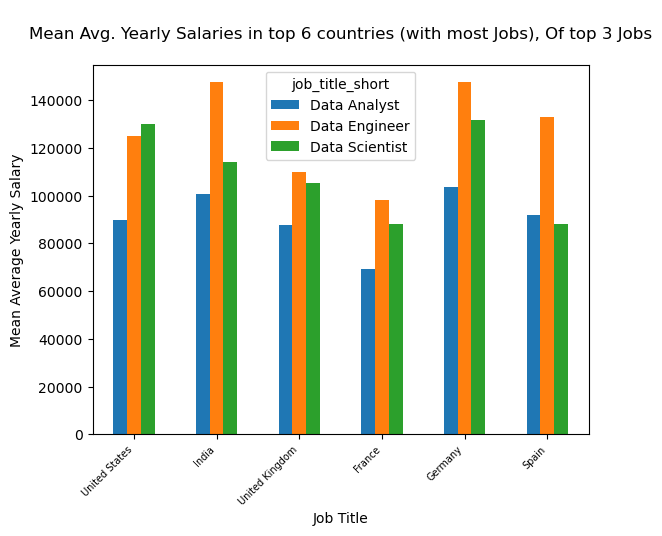

In [9]:
# Top 6 countries --> countries with Most Job Postings, irrespective of job_title_short
top_6_countries_list = df['job_country'].value_counts().head(6)
# print(top_6_countries_list, end = "\n\n\n")

# Top 3 Jobs worldwide
target_jobs = df['job_title_short'].value_counts().head(3);
# print(target_jobs)

# .index is necessary because the index contains the labels, and .loc[] needs proper labels, #  not indices
target_plot = df.pivot_table(index='job_country', columns='job_title_short', values='salary_year_avg', aggfunc='median', fill_value=0).loc[top_6_countries_list.index, target_jobs.index]


# Plotting in already pivoted data, no need for X or Y labels
target_plot.plot(kind = "bar")
plt.title("\nMean Avg. Yearly Salaries in top 6 countries (with most Jobs), Of top 3 Jobs\n")
plt.ylabel("Mean Average Yearly Salary")
plt.xlabel("Job Title")
plt.xticks(rotation = 45, ha = "right", fontsize = 7)
plt.show()

